In [157]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import LogisticRegression

import lightgbm as lgb
import xgboost as xgb
import catboost as cb

SEED = 42
N_FOLDS = 5
np.random.seed(SEED)

In [158]:
df_train = pd.read_csv('irrigation_train.csv')
df_train.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [159]:
df_test = pd.read_csv('irrigation_test.csv')
df_test.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,630000,Silt,6.36,26.19,0.59,2.81,17.83,30.24,1533.38,5.40,3.00,Maize,Sowing,Rabi,Canal,River,13.59,Yes,47.48,West
1,630001,Clay,5.87,9.88,1.18,3.26,21.18,78.07,576.05,7.22,15.88,Cotton,Sowing,Rabi,Drip,Reservoir,6.12,Yes,56.43,South
2,630002,Sandy,6.22,26.55,0.96,0.85,26.87,60.35,545.30,9.43,2.63,Wheat,Sowing,Kharif,Sprinkler,Reservoir,3.11,Yes,20.00,East
3,630003,Clay,7.68,53.58,0.83,0.55,41.74,36.05,1211.03,6.69,1.86,Maize,Harvest,Rabi,Canal,Groundwater,2.27,No,102.99,North
4,630004,Loamy,5.23,59.02,0.54,2.11,41.08,52.47,1321.91,4.11,5.71,Cotton,Sowing,Kharif,Canal,Groundwater,12.39,Yes,13.33,Central


In [160]:
df_original = pd.read_csv('irrigation_prediction_original.csv')
df_original.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rabi,Rainfed,Reservoir,4.73,Yes,1.98,South,Low
1,Silt,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Maize,Flowering,Zaid,Canal,Groundwater,12.22,Yes,33.56,Central,Medium
2,Sandy,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,Cotton,Harvest,Rabi,Drip,Reservoir,5.52,Yes,34.62,South,Low
3,Clay,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,Wheat,Sowing,Kharif,Canal,Reservoir,1.43,Yes,84.03,North,Medium
4,Clay,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,Cotton,Sowing,Zaid,Canal,River,2.52,No,60.86,South,Medium


In [161]:
print(f"Train Set Shape : {df_train.shape}")
print(f"Test Set Shape : {df_test.shape}")
print(f"Original Dataset Shape : {df_original.shape}")

Train Set Shape : (630000, 21)
Test Set Shape : (270000, 20)
Original Dataset Shape : (10000, 20)


In [162]:
df_train = df_train.drop(['id'], axis=1)

In [163]:
test_id = df_test['id']
submission_df = pd.DataFrame({'id': test_id})
df_test = df_test.drop(['id'], axis=1)

In [164]:
ntrain = df_train.shape[0]    # No of rows in Train dataset
ntest = df_test.shape[0]      # No of rows in Test dataset
df_train['Irrigation_Need'] = df_train['Irrigation_Need'].map({"Low":0, "Medium":1, "High":2})
df_original['Irrigation_Need'] = df_original['Irrigation_Need'].map({"Low":0, "Medium":1, "High":2})
reverse_mapping = {0:"Low", 1:"Medium", 2:"High"}

# Combined Dataset
train_full = pd.concat([df_train, df_original], axis=0).reset_index(drop=True)
y = train_full['Irrigation_Need']

train_full.drop(['Irrigation_Need'], axis=1, inplace=True)
print(f"Size of the whole dataset : {train_full.shape}")

Size of the whole dataset : (640000, 19)


In [165]:
cat_cols = train_full.select_dtypes(include='object').columns.to_list()
num_cols = train_full.select_dtypes(exclude='object').columns.to_list()

# Data-Preprocessing

**Feature Engineering** :

In [119]:
def engineer_features(data):
    df = data.copy()

    # Water balance features
    df['Total_Water_Intake'] = df['Rainfall_mm'] + df['Previous_Irrigation_mm']
    
    df['Evaporative_Stress'] = (df['Temperature_C'] * df['Wind_Speed_kmh'] * df['Sunlight_Hours'])/(df['Humidity']+1)
    
    df['Water_Balance'] = df['Total_Water_Intake'] - df['Evaporative_Stress'] * df['Field_Area_hectare']
    
    df['Atmosphere_Soil_Moisture_Gap'] = df['Humidity'] - df['Soil_Moisture']

    # Crop-relative moisture (target encoding proxy - no leakage)
    moisture_map = df.groupby('Crop_Type')['Soil_Moisture'].mean()
    
    df['Relative_Crop_Moisture'] = df['Soil_Moisture'] / df['Crop_Type'].map(moisture_map).fillna(1.0)

    # Mulch interaction
    df['Mulch_Moisture'] = df['Soil_Moisture'] * df['Mulching_Used'].map({'Yes':1.5, 'No':1})

    # Soil health features
    df['Soil_Health'] = (df['Organic_Carbon'] * df['Soil_Moisture'])/(df['Electrical_Conductivity']+1.0)
    
    df['pH_deviation'] = np.abs(df['Soil_pH'] - 6.5)
    
    df['Soil_Salinity_Risk'] = (df['Electrical_Conductivity'] * df['Temperature_C'])/(df['Rainfall_mm']+1)
    
    # Field efficiency
    df['Irrigation_Per_Hectare'] = df['Previous_Irrigation_mm']/(df['Field_Area_hectare']+1.0)
    
    df['Rainfall_Per_Hectare'] = df['Rainfall_mm']/(df['Field_Area_hectare']+1.0)

    # Climate stress features
    df['Moisture_Retention'] = df['Soil_Moisture'] * df['Organic_Carbon']
    
    df['Moisture_Temp_Ratio'] = df['Soil_Moisture'] / (df['Temperature_C'] + 1)

    # Crop-soil-season interactions (encoded as grouped stats)
    for grp_col in ['Soil_Type', 'Season', 'Crop_Growth_Stage']:
        grp_key = f'{grp_col}_Moisture_mean'
        grp = df.groupby(grp_col)['Soil_Moisture'].transform('mean')
        df[f'{grp_col}_Moisture_dev'] = df['Soil_Moisture'] - grp

    return df

In [120]:
df_train = engineer_features(train_full)
df_test = engineer_features(df_test)

**Target & Categorical Encoding** :

In [121]:
# Unify categories across train/test
for col in cat_cols:
    combined_cats = pd.concat([df_train[col], df_test[col]]).astype('str').unique()
    df_train[col] = pd.Categorical(df_train[col], categories=combined_cats)
    df_test[col] = pd.Categorical(df_test[col], categories=combined_cats)

for col in cat_cols:
    df_train[col] = df_train[col].astype('category')
    df_test[col] = df_test[col].astype('category')

In [122]:
X_train = df_train.copy()
X_test = df_test.copy()

**GPU-Accelerated Model Training** :

In [123]:
lgb_params = dict(
    device='cpu', n_estimators=500, learning_rate=0.1,
    num_leaves=31, max_depth=6, class_weight='balanced', verbose=-1
)

xgb_params = dict(
    device='cpu', tree_method='hist', enable_categorical=True,
    n_estimators=500, learning_rate=0.1, max_depth=6
)

cat_params = dict(
    task_type='CPU', iterations=300, learning_rate=0.1,
    depth=5, auto_class_weights='Balanced',
    cat_features=cat_cols, verbose=0
)

model_configs = [
    ('lgb', lgb.LGBMClassifier, lgb_params, False),
    ('xgb', xgb.XGBClassifier, xgb_params, True),
    ('cat', cb.CatBoostClassifier, cat_params, False),
]

print(f'{len(model_configs)} model configs ready (GPU, ~5 min total)')

3 model configs ready (GPU, ~5 min total)


**5-Fold CV Training with All Models** :

In [124]:
print(X_test.shape)

(270000, 35)


In [125]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
sample_weights = compute_sample_weight('balanced', y)

# Storage for OOF and test predictions
n_models = len(model_configs)
oof_preds = {name : np.zeros((df_train.shape[0], 3)) for name, _,_,_ in model_configs}
test_preds = {name : np.zeros((df_test.shape[0], 3)) for name, _,_,_ in model_configs}

for fold, (train_idx, validation_idx) in enumerate(skf.split(X_train, y)):
    print(f"=== Fold {fold + 1}: ===")

    xt, xv = X_train.iloc[train_idx], X_train.iloc[validation_idx]
    yt, yv = y[train_idx], y[validation_idx]

    wt = sample_weights[train_idx]
    
    for model_name, ModelClass, params, use_sample_wts in model_configs:
        model = ModelClass(**params)
        
        if use_sample_wts:
            model.fit(xt, yt, sample_weight=wt)
        else:
            model.fit(xt, yt)

        oof_preds[model_name][validation_idx] = model.predict_proba(xv)
        test_preds[model_name] += model.predict_proba(X_test)/N_FOLDS

        score = balanced_accuracy_score(yv, oof_preds[model_name][validation_idx].argmax(axis=1))
        print(f"{model_name} : {score}")

=== Fold 1: ===
lgb : 0.9690764182445201
xgb : 0.9691058618133702
cat : 0.9689257155659338
=== Fold 2: ===
lgb : 0.9690993475888159
xgb : 0.969168286179176
cat : 0.9672084967683433
=== Fold 3: ===
lgb : 0.9687050986904638
xgb : 0.9694046259854016
cat : 0.9683146550527119
=== Fold 4: ===
lgb : 0.9691548421201485
xgb : 0.9700474440755761
cat : 0.969293813585202
=== Fold 5: ===
lgb : 0.9649613102999887
xgb : 0.9654090300204076
cat : 0.9654538106887346


In [126]:
print(f'\n=== Overall OOF Balanced Accuracy ===')
for name in oof_preds:
    score = balanced_accuracy_score(y, oof_preds[name].argmax(axis=1))
    print(f"{name} : {score}")


=== Overall OOF Balanced Accuracy ===
lgb : 0.968199403988749
xgb : 0.9686270502237391
cat : 0.9678392997606698


In [133]:
# Level 2 : Stacking with Logistic Regression
oof_stack = np.hstack([oof_preds[name] for name in oof_preds])
test_stack = np.hstack([test_preds[name] for name in test_preds])
print(f'Meta-features: {oof_stack.shape[1]} (3 probs x {n_models} models)')  # 3 probs ===> 3 classes, irrigation_need = low/medium/high

# Simple average baseline
avg_oof = np.mean([oof_preds[name] for name in oof_preds], axis=0)
avg_test = np.mean([test_preds[name] for name in test_preds], axis=0)
avg_score = balanced_accuracy_score(y, avg_oof.argmax(axis=1))
print(f'Simple average OOF balanced accuracy: {avg_score:.5f}')


meta_oof_preds = np.zeros(len(y), dtype=int)
meta_test_preds = np.zeros((len(X_test), 3))

for fold, (train_idx, validation_idx) in enumerate(skf.split(X_train, y)):
    meta_model = LogisticRegression(class_weight='balanced', max_iter=2000, C=1.0, random_state=SEED)
    meta_model.fit(oof_stack[train_idx], y[train_idx])

    meta_oof_preds[validation_idx] = meta_model.predict(oof_stack[validation_idx])
    meta_test_preds += meta_model.predict_proba(test_stack) / N_FOLDS
    
stack_score = balanced_accuracy_score(y, meta_oof_preds)
print(f'Stacked meta-learner OOF balanced accuracy: {stack_score:.5f}')

# Also train final meta-model on all data
final_meta_model = LogisticRegression(class_weight='balanced', max_iter=2000, C=1.0, random_state=SEED)
final_meta_model.fit(oof_stack, y)
final_meta_test = final_meta_model.predict_proba(test_stack)

# Pick best approach
if stack_score >= avg_score:
    print('\n>>> Using stacked meta-learner predictions')
    final_test_probs = final_meta_test
    best_oof_probs = np.zeros((len(y), 3))
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y)):
        meta = LogisticRegression(class_weight='balanced', max_iter=2000, C=1.0, random_state=SEED)
        meta.fit(oof_stack[tr_idx], y[tr_idx])
        best_oof_probs[val_idx] = meta.predict_proba(oof_stack[val_idx])
else:
    print('\n>>> Using simple average predictions')
    final_test_probs = avg_test
    best_oof_probs = avg_oof

Meta-features: 9 (3 probs x 3 models)
Simple average OOF balanced accuracy: 0.96908
Stacked meta-learner OOF balanced accuracy: 0.97068

>>> Using stacked meta-learner predictions


**Threshold Optimization for Balanced Accuracy**

In [137]:
best_w = [1.0, 1.0, 1.0]
best_adj_score = balanced_accuracy_score(y, best_oof_probs.argmax(1))

for w_high in np.arange(1.0, 5.1, 0.2):
    for w_low in np.arange(0.8, 1.6, 0.1):
        w = np.array([1.0, w_low, w_high])
        adjusted = best_oof_probs * w[np.newaxis, :]
        preds = adjusted.argmax(axis=1)
        score = balanced_accuracy_score(y, preds)
        if score > best_adj_score:
            best_adj_score = score
            best_w = w.tolist()

print(f'Best class weights: Low={best_w[0]:.1f}, Medium={best_w[1]:.1f}, High={best_w[2]:.1f}')
print(f'Adjusted OOF balanced accuracy: {best_adj_score:.5f}')
print(f'Improvement over raw: +{best_adj_score - balanced_accuracy_score(y, best_oof_probs.argmax(1)):.5f}')

Best class weights: Low=1.0, Medium=0.8, High=1.2
Adjusted OOF balanced accuracy: 0.97102
Improvement over raw: +0.00034


**Analysis & Visualization**

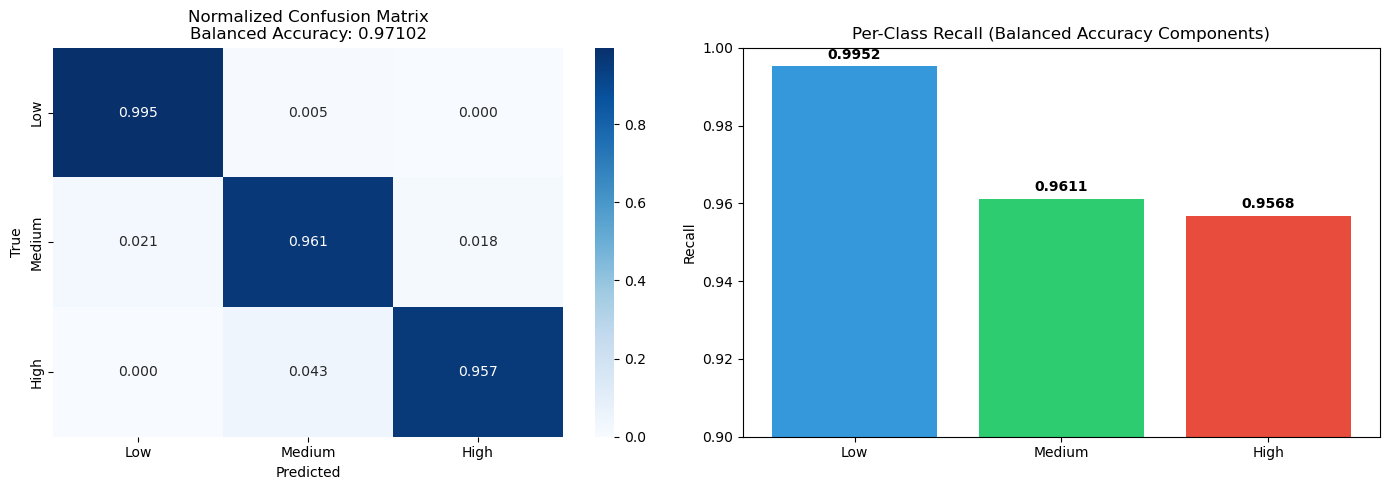


Classification Report:
              precision    recall  f1-score   support

         Low       0.99      1.00      0.99    375781
      Medium       0.99      0.96      0.97    242874
        High       0.83      0.96      0.89     21345

    accuracy                           0.98    640000
   macro avg       0.93      0.97      0.95    640000
weighted avg       0.98      0.98      0.98    640000



In [138]:
adjusted_oof = best_oof_probs * np.array(best_w)[np.newaxis, :]
oof_final = adjusted_oof.argmax(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y, oof_final, normalize='true')
sns.heatmap(cm, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'], ax=axes[0])
axes[0].set_title(f'Normalized Confusion Matrix\nBalanced Accuracy: {best_adj_score:.5f}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

recalls = cm.diagonal()
colors = ['#3498db', '#2ecc71', '#e74c3c']
axes[1].bar(['Low', 'Medium', 'High'], recalls, color=colors)
axes[1].set_title('Per-Class Recall (Balanced Accuracy Components)')
axes[1].set_ylabel('Recall')
axes[1].set_ylim(0.9, 1.0)
for i, (cls, r) in enumerate(zip(['Low', 'Medium', 'High'], recalls)):
    axes[1].text(i, r + 0.002, f'{r:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('\nClassification Report:')
print(classification_report(y, oof_final, target_names=['Low', 'Medium', 'High']))

In [151]:
lgb_params = dict(
    device='cpu', n_estimators=500, learning_rate=0.1,
    num_leaves=31, max_depth=6, class_weight='balanced', verbose=-1
)
model = lgb.LGBMClassifier(**lgb_params)
model.fit(X_train, y)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.1
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


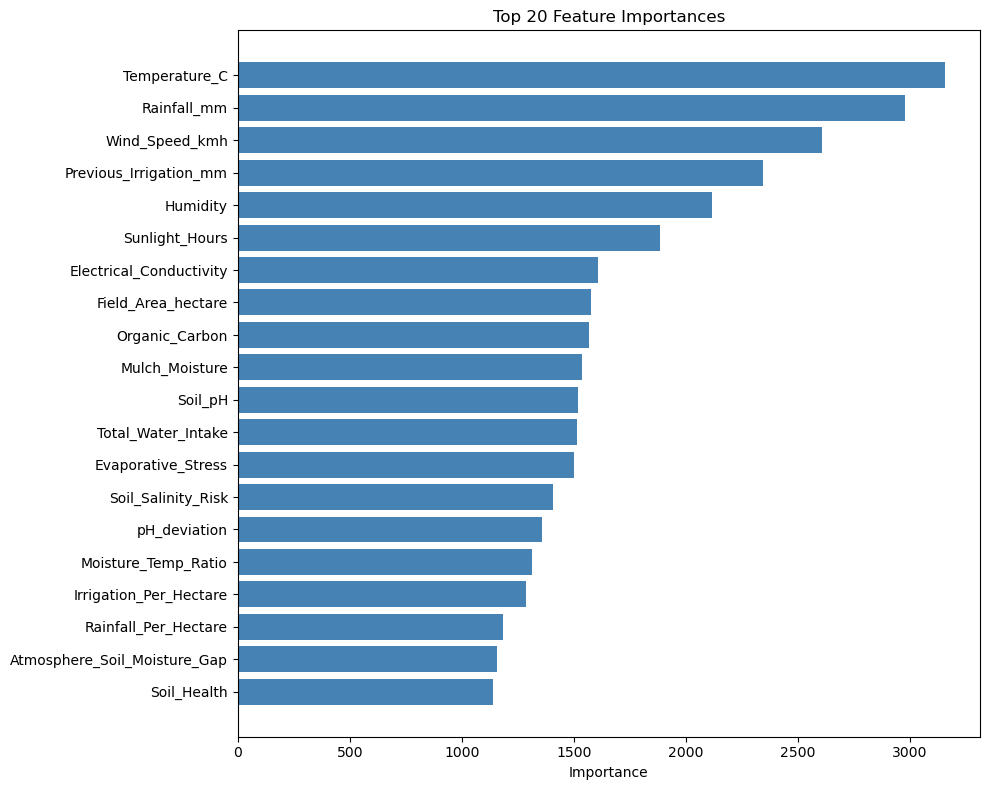

In [154]:
feature_cols = X_train.columns.to_list()

# Feature importance (from last LightGBM model)
fi = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_ if hasattr(model, 'feature_importances_') else np.zeros(len(feature_cols))
}).sort_values('importance', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(fi['feature'], fi['importance'], color='steelblue')
ax.set_title('Top 20 Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

In [167]:
# Apply optimized class weights to final test predictions
final_adjusted = final_test_probs * np.array(best_w)[np.newaxis, :]
final_preds = final_adjusted.argmax(axis=1)
final_labels = [reverse_mapping[p] for p in final_preds]

submission = pd.DataFrame({'id': test_id, 'Irrigation_Need': final_labels})
submission.to_csv('submission.csv', index=False)

print('Submission shape:', submission.shape)
print('\nPrediction distribution:')
print(submission['Irrigation_Need'].value_counts(normalize=True))
print('\nFirst 10 rows:')
print(submission.head(10))
print('\nSubmission saved!')

Submission shape: (270000, 2)

Prediction distribution:
Irrigation_Need
Low       0.591889
Medium    0.369615
High      0.038496
Name: proportion, dtype: float64

First 10 rows:
       id Irrigation_Need
0  630000             Low
1  630001             Low
2  630002             Low
3  630003             Low
4  630004             Low
5  630005          Medium
6  630006             Low
7  630007          Medium
8  630008            High
9  630009             Low

Submission saved!
